In [42]:
#pip install optuna-dashboard

Note: you may need to restart the kernel to use updated packages.


In [43]:
import os
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

DG_folder0='data_aug01'
images_increased = 8

try:
    os.mkdir(DG_folder0)
except:
    print("")
    
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False)


data_path = r"Art_brut"
data_dir_list = os.listdir(data_path)

width_shape, height_shape = 224, 224

i=0
num_images=0
for image_file in data_dir_list:
    img_list=os.listdir(data_path)

    img_path = data_path + '/'+ image_file

    imge=load_img(img_path)
    
    imge=cv2.resize(img_to_array(imge), (width_shape, height_shape), interpolation = cv2.INTER_AREA)
    x= imge/255
    x=np.expand_dims(x,axis=0)
    t=1
    for output_batch in train_datagen.flow(x,batch_size=1):
        a=img_to_array(output_batch[0])
        imagen=output_batch[0,:,:]*255
        imgfinal = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
        cv2.imwrite(DG_folder0+"/%i%i.jpg"%(i,t), imgfinal) 
        t+=1
        
        num_images+=1
        if t>images_increased:
            break
    i+=1
    
print("images generated",num_images)


images generated 3800


In [14]:
import os
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

DG_folder1='data_aug12'
images_increased = 8

try:
    os.mkdir(DG_folder1)
except:
    print("")
    
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False)


data_path = r"imagenes/Abstract_Expressionism/"
data_dir_list = os.listdir(data_path)

width_shape, height_shape = 224, 224

i=0
num_images=0
for image_file in data_dir_list:
    img_list=os.listdir(data_path)

    img_path = data_path + '/'+ image_file
    try:
        imge=load_img(img_path)
        
        imge=cv2.resize(img_to_array(imge), (width_shape, height_shape), interpolation = cv2.INTER_AREA)
        x= imge/255
        x=np.expand_dims(x,axis=0)
        t=1
        for output_batch in train_datagen.flow(x,batch_size=1):
            a=img_to_array(output_batch[0])
            imagen=output_batch[0,:,:]*255
            imgfinal = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
            cv2.imwrite(DG_folder1+"/%i%i.jpg"%(i,t), imgfinal) 
            t+=1
            
            num_images+=1
            if t>images_increased:
                break
        i+=1
    except PermissionError as e:
        print(e)
    
print("images generated",num_images)

PermissionError: [Errno 13] Permission denied: 'imagenes/Abstract_Expressionism//output'

In [3]:
import os
import random
import shutil
from skimage.io import imread_collection
from torch.utils.data import random_split

imagenes_brut = imread_collection('data_aug01/*.jpg')
imagenes_realism = imread_collection('data_aug12/*.jpg')

#directorios donde se encuentran las imagenes 
directorio_brut = "data_aug01/"
directorio_realism = "data_aug12/"

carpeta = ['train','test','val']
estilo = ['brut','Abstract_Expressionism']
#dIRECTORIOS DE SALIDA
directorios =[]
for i in range(3):
    for j in range(2):
        nombre_directorio = f"directorio_{carpeta[i]}_{estilo[j]}"
        x = os.path.join ("data6",carpeta[i],estilo[j])
        directorios.append(x)

In [4]:
directorios

['data6\\train\\brut',
 'data6\\train\\Abstract_Expressionism',
 'data6\\test\\brut',
 'data6\\test\\Abstract_Expressionism',
 'data6\\val\\brut',
 'data6\\val\\Abstract_Expressionism']

In [ ]:
#Crear directorios si no existen
for directorio in directorios:
    if not os.path.exists(directorio):
        os.makedirs(directorio)

im_files_brut = os.listdir(directorio_brut)
im_files_realism = os.listdir(directorio_realism)

# Calcula el tamaño para cada conjunto
def tamaño_conjunto(dataset):
    train_ratio = 0.6
    val_ratio = 0.3
    test_ratio = 0.1
    total_size = len(dataset)
    train_size = int(train_ratio * total_size)
    val_size = int(val_ratio * total_size)
    test_size = total_size - train_size - val_size
    return(total_size,train_size,test_size,val_size)

n,train_size,test_size,val_size = tamaño_conjunto(imagenes_realism)

#m,train_size,test_size,val_size = tamaño_conjunto(imagenes_brut)

im_files_brut = random.sample(im_files_brut, n)
im_files_realism = random.sample(im_files_realism, n)

imagenes_train_brut, rest_dataset1 = random_split(im_files_brut, [train_size, n - train_size])
imagenes_val_brut, imagenes_test_brut = random_split(rest_dataset1, [val_size, test_size])

imagenes_train_realism, rest_dataset2 = random_split(im_files_realism, [train_size, n - train_size])
imagenes_val_realism, imagenes_test_realism = random_split(rest_dataset2, [val_size, test_size])

imagenes = [imagenes_train_brut,imagenes_train_realism,imagenes_test_brut,imagenes_test_realism,imagenes_val_brut,imagenes_val_realism]

for i,lista in enumerate(imagenes):
    if i%2==0:
        print(i)
        for j in lista:
        
            #print(directorios[i],lista,'par realism')
            ruta_origen = os.path.join(directorio_realism,j)
            ruta_destino = os.path.join(directorios[i],j)
            try:
                shutil.copy(ruta_origen,ruta_destino)
            except:
                print('error') 
    else:
        for k in lista:
            
            #print(directorios[i],lista,'impar, brut')
            ruta_origen = os.path.join(directorio_brut,k)
            ruta_destino = os.path.join(directorios[i], k)
            try:
                shutil.copy(ruta_origen,ruta_destino)
            except:
                print('error')

In [6]:
import pandas as pd

save_file_name = 'vgg16-transfer-4.pt'
checkpoint_path = 'vgg16-transfer-4.pth'

# Directorio principal que contiene los datos
data_dir = 'data6/'

# Lista para almacenar la información de cada imagen
lista_train = []
lista_test = []
lista_val = []
# Iterar sobre las carpetas de train, test y validation
for split in ['train', 'test', 'val']:
    split_dir = os.path.join(data_dir, split)
    for clase in os.listdir(split_dir):
        clase_dir = os.path.join(split_dir, clase)
        for filename in os.listdir(clase_dir):
            # Generar la ruta completa del archivo
            path = os.path.join(clase_dir, filename)
            # Obtener el nombre de la clase y el índice de clase a partir del nombre del directorio
            class_index = 0 if clase == 'brut' else 1
            # Agregar la información de la imagen a la lista
            if split == 'train':
                lista_train.append((filename, path, clase, class_index))
            elif split == 'test':
                lista_test.append((filename, path, clase, class_index))
            else:
                lista_val.append((filename, path, clase, class_index))

# Crear el DataFrame
df_train = pd.DataFrame(lista_train, columns=['file_name', 'file_path', 'class_name', 'class_index'])
df_test = pd.DataFrame(lista_test, columns=['file_name', 'file_path', 'class_name', 'class_index'])
df_val = pd.DataFrame(lista_val, columns=['file_name', 'file_path', 'class_name', 'class_index'])
# Guardar el DataFrame en un archivo CSV
df_train.to_csv('etiquetas_train6.csv', index=False)
df_test.to_csv('etiquetas_test6.csv', index=False)
df_val.to_csv('etiquetas_val6.csv', index=False)


print("CSV generado exitosamente.")

CSV generado exitosamente.


In [1]:
import torch

class Dataset_imagenes(torch.utils.data.Dataset):
    def __init__(self,etiquetas,img_dir="",transforms=None):
        self.etiquetas_df = pd.read_csv(etiquetas,delimiter=',', header=0)
        self.img_dir = img_dir
        self.transform = transforms
        self.clase_a_indice = {
            'brut': 0,
            'Abstract_Expressionism': 1
        }

    def __len__(self):
        return len(self.etiquetas_df)
    
    def __getitem__(self, idx):
        self.loaded_data = []
        directorio_imagen = os.path.join(self.img_dir, self.etiquetas_df.iloc[idx, 1]) 
        imagen = cv2.imread(directorio_imagen) 
        imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
        clase = self.etiquetas_df.iloc[idx, 2]
        clase_indice = self.clase_a_indice[clase]
        clase_tensor = torch.tensor(clase_indice, dtype=torch.long)
        if self.transform:
            imagen = self.transform(imagen)      
        return imagen, clase_tensor

In [2]:
from torchvision import transforms
import pandas as pd

t0=transforms.Compose([transforms.ToTensor(),transforms.Resize((224,224)),transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) ])

set_datos_train = Dataset_imagenes(etiquetas ='etiquetas_train6.csv',img_dir="",transforms=t0)
set_datos_test = Dataset_imagenes(etiquetas ='etiquetas_test6.csv',img_dir="",transforms=t0)
set_datos_val = Dataset_imagenes(etiquetas ='etiquetas_val6.csv',img_dir="",transforms=t0) 



In [3]:
from torch.utils.data import DataLoader

# Ahora puedes crear un DataLoader para el conjunto de datos combinado
batch_size = 32
#dataloader = DataLoader(combined_dataset, batch_size=numBatch, shuffle=True)

'''
plt.figure(figsize=(12,6))
#Accedemos a 5 registros del dataloader
for i in enumerate(dataloader): 
    imagen = i[1][0][0]
    clase = i[1][1][0]
    ax=plt.subplot(2,5,i[0]+1) 
    ax.title.set_text(clase) 
    imagen_T = np.transpose(imagen, (1, 2, 0))
    plt.imshow(imagen_T)
    if i[0]==4:
        break
''' 

train_loader = DataLoader(set_datos_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(set_datos_test, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(set_datos_val, batch_size=batch_size, shuffle=True)


In [4]:
import torch.nn as nn
import numpy as np
from timeit import default_timer as timer

save_file_name = 'vgg16-transfer-4.pt'
checkpoint_path = 'vgg16-transfer-4.pth'


if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(device)

criterion = nn.NLLLoss()

def train1(model,criterion,optimizer,train_loader,valid_loader,save_file_name,
          max_epochs_stop,n_epochs,print_every=1):
    """Train a PyTorch Model

    Params
    --------
        model (PyTorch model): cnn to train
        criterion (PyTorch loss): objective to minimize
        optimizer (PyTorch optimizier): optimizer to compute gradients of model parameters
        train_loader (PyTorch dataloader): training dataloader to iterate through
        valid_loader (PyTorch dataloader): validation dataloader used for early stopping
        save_file_name (str ending in '.pt'): file path to save the model state dict
        max_epochs_stop (int): maximum number of epochs with no improvement in validation loss for early stopping
        n_epochs (int): maximum number of training epochs
        print_every (int): frequency of epochs to print training stats

    Returns
    --------
        model (PyTorch model): trained cnn with best weights
        history (DataFrame): history of train and validation loss and accuracy
    """

    # Early stopping intialization
    epochs_no_improve = 0
    valid_loss_min = np.Inf

    valid_max_acc = 0
    history = []
    try:
        model.load_state_dict(torch.load(checkpoint_path))
        model.optimizer = optimizer
    except FileNotFoundError:
        print('no hay modelo....')
    except Exception as e:
        print(f'error inesperado: {e}')    
    # Number of epochs already trained (if using loaded in model weights)
    try:
        print(f'Model has been trained for: {model.epochs} epochs.\n')
    except:
        model.epochs = 0
        print(f'Starting Training from Scratch.\n')

    overall_start = timer()

    # Main loop
    for epoch in range(n_epochs):

        # keep track of training and validation loss each epoch
        train_loss = 0.0
        valid_loss = 0.0

        train_acc = 0
        valid_acc = 0

        # Set to training
        model.train()
        start = timer()

        # Training loop
        for ii, (data, target) in enumerate(train_loader):
            # Tensors to gpu
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()
            else:
                data = data.to(device=device, dtype=torch.float32)
                target = target.to(device=device, dtype=torch.long)

            # Clear gradients
            optimizer.zero_grad()
            # Predicted outputs are log probabilities
            output = model(data)

            # Loss and backpropagation of gradients
            loss = criterion(output, target)
            loss.backward()

            # Update the parameters
            optimizer.step()

            # Track train loss by multiplying average loss by number of examples in batch
            train_loss += loss.item() * data.size(0)

            # Calculate accuracy by finding max log probability
            _, pred = torch.max(output, dim=1)
            correct_tensor = pred.eq(target.data.view_as(pred))
            # Need to convert correct tensor from int to float to average
            accuracy = torch.mean(correct_tensor.type(torch.FloatTensor))
            # Multiply average accuracy times the number of examples in batch
            train_acc += accuracy.item() * data.size(0)

            # Track training progress
            print(
                f'Epoch: {epoch}\t{100 * (ii + 1) / len(train_loader):.2f}% complete. {timer() - start:.2f} seconds elapsed in epoch.',
                end='\r')

        # After training loops ends, start validation
        else:
            model.epochs += 1

            # Don't need to keep track of gradients
            with torch.no_grad():
                # Set to evaluation mode
                model.eval()

                # Validation loop
                for data, target in valid_loader:
                    # Tensors to gpu
                    if torch.cuda.is_available():
                        data, target = data.cuda(), target.cuda()
                    else:
                        data = data.to(device=device, dtype=torch.float32)
                        target = target.to(device=device, dtype=torch.long)

                    # Forward pass
                    
                    output = model(data)

                    # Validation loss
                    loss = criterion(output, target)
                    # Multiply average loss times the number of examples in batch
                    valid_loss += loss.item() * data.size(0)

                    # Calculate validation accuracy
                    _, pred = torch.max(output, dim=1)
                    correct_tensor = pred.eq(target.data.view_as(pred))
                    accuracy = torch.mean(
                        correct_tensor.type(torch.FloatTensor))
                    # Multiply average accuracy times the number of examples
                    valid_acc += accuracy.item() * data.size(0)

                # Calculate average losses
                train_loss = train_loss / len(train_loader.dataset)
                valid_loss = valid_loss / len(valid_loader.dataset)

                # Calculate average accuracy
                train_acc = train_acc / len(train_loader.dataset)
                valid_acc = valid_acc / len(valid_loader.dataset)

                history.append([train_loss, valid_loss, train_acc, valid_acc])

                # Print training and validation results
                if (epoch + 1) % print_every == 0:
                    print(
                        f'\nEpoch: {epoch} \tTraining Loss: {train_loss:.4f} \tValidation Loss: {valid_loss:.4f}'
                    )
                    print(
                        f'\t\tTraining Accuracy: {100 * train_acc:.2f}%\t Validation Accuracy: {100 * valid_acc:.2f}%'
                    )

                # Save the model if validation loss decreases
                if valid_loss < valid_loss_min:
                    # Save model
                    torch.save(model.state_dict(), save_file_name)
                    # Track improvement
                    epochs_no_improve = 0
                    valid_loss_min = valid_loss
                    valid_best_acc = valid_acc
                    best_epoch = epoch

                # Otherwise increment count of epochs with no improvement
                else:
                    epochs_no_improve += 1
                    # Trigger early stopping
                    if epochs_no_improve >= max_epochs_stop:
                        print(
                            f'\nEarly Stopping! Total epochs: {epoch}. Best epoch: {best_epoch} with loss: {valid_loss_min:.2f} and acc: {100 * valid_acc:.2f}%'
                        )
                        total_time = timer() - overall_start
                        print(
                            f'{total_time:.2f} total seconds elapsed. {total_time / (epoch+1):.2f} seconds per epoch.'
                        )

                        # Load the best state dict
                        model.load_state_dict(torch.load(save_file_name))
                        # Attach the optimizer
                        model.optimizer = optimizer

                        # Format history
                        history = pd.DataFrame(
                            history,
                            columns=[
                                'train_loss', 'valid_loss', 'train_acc',
                                'valid_acc'
                            ])
                        return model, history

    # Attach the optimizer
    model.optimizer = optimizer
    # Record overall time and print out stats
    total_time = timer() - overall_start
    print(
        f'\nBest epoch: {best_epoch} with loss: {valid_loss_min:.2f} and acc: {100 * valid_best_acc:.2f}%'
    )
    print(
        f'{total_time:.2f} total seconds elapsed. {total_time / (epoch):.2f} seconds per epoch.'
    )
    # Format history
    history = pd.DataFrame(
        history,
        columns=['train_loss', 'valid_loss', 'train_acc', 'valid_acc'])
    return model, history


cuda


In [5]:

#Librerias....
import csv
import os
import cv2
import random
from torchvision import transforms
from torchvision.utils import save_image
from torch import optim, cuda
from torchsummary import summary
import PIL
from PIL import Image
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data.dataloader import default_collate
import torch
from torch.utils.data import DataLoader, ConcatDataset
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch.utils.data import random_split
from torchvision import models
from timeit import default_timer as timer

In [6]:
from torchvision import models
from torchsummary import summary
from torch import optim
import torch.nn as nn

def get_pretrained_model(model_name):

    if model_name == 'vgg16':
        model = models.vgg16(weights=("pretrained", "default_weights"))

        # Freeze early layers
        for param in model.parameters():
            param.requires_grad = False
        n_inputs = model.classifier[6].in_features
        # Add on classifier
        '''model.classifier[6] = nn.Sequential(
            nn.Linear(n_inputs, 256), nn.ReLU(), nn.Dropout(0.255),
            nn.Linear(256, 2), nn.LogSoftmax(dim=1))'''
        
        model.classifier[6] = nn.Sequential(
        nn.Linear(n_inputs, 1024), nn.ReLU(), nn.Dropout(0.255),
        nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.255),
        nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.255),
        nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.255),
        nn.Linear(128, 2), nn.LogSoftmax(dim=1)   )

    # Move to gpu and parallelize
    if torch.cuda.is_available():
        model = model.to('cuda')
    return model

model_vgg16 = get_pretrained_model('vgg16')
lr = 8.754253089076799e-05
summary(model_vgg16, input_size=(3, 224, 224), batch_size=batch_size, device='cuda')
optimizer = optim.Adam(model_vgg16.parameters(),lr=lr)

model1, history1 = train1(
    model_vgg16,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    save_file_name,
    max_epochs_stop=15,
    n_epochs=100,
    print_every=1)

c:\Users\UsuarioCompuElite\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [32, 64, 224, 224]           1,792
              ReLU-2         [32, 64, 224, 224]               0
            Conv2d-3         [32, 64, 224, 224]          36,928
              ReLU-4         [32, 64, 224, 224]               0
         MaxPool2d-5         [32, 64, 112, 112]               0
            Conv2d-6        [32, 128, 112, 112]          73,856
              ReLU-7        [32, 128, 112, 112]               0
            Conv2d-8        [32, 128, 112, 112]         147,584
              ReLU-9        [32, 128, 112, 112]               0
        MaxPool2d-10          [32, 128, 56, 56]               0
           Conv2d-11          [32, 256, 56, 56]         295,168
             ReLU-12          [32, 256, 56, 56]               0
           Conv2d-13          [32, 256, 56, 56]         590,080
             ReLU-14          [32, 256,

In [ ]:
test_loss=0
test_acc = 0
#Abstract_Expressionism

with torch.no_grad():
    # Set to evaluation mode
    model1.eval()

    # Validation loop
    for data, target in test_loader:
        # Tensors to gpu
        if torch.cuda.is_available():
            data, target = data.cuda(), target.cuda()
        else:
            data = data.to(device=device, dtype=torch.float32)
            target = target.to(device=device, dtype=torch.long)

        # Forward pass
        
        output = model1(data)
        # Validation loss
        loss = criterion(output, target)
        # Multiply average loss times the number of examples in batch
        test_loss += loss.item() * data.size(0)

        # Calculate validation accuracy
        _, pred = torch.max(output, dim=1)
        correct_tensor = pred.eq(target.data.view_as(pred))
        accuracy = torch.mean(
            correct_tensor.type(torch.FloatTensor))
        # Multiply average accuracy times the number of examples
        test_acc += accuracy.item() * data.size(0)

    # Calculate average losses
    test_loss = test_loss / len(test_loader.dataset)

    # Calculate average accuracy
    test_acc = test_acc / len(test_loader.dataset)

    print(f'accuracy test es igual a: {test_acc} y loss test es : {test_loss}')

accuracy test es igual a: 0.9883720930232558 y loss test es : 0.044967108390784945


In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
confusion_matrices = []
predicted = []
actual = []
for inputs, target in test_loader :
    if torch.cuda.is_available():
        inputs, target = inputs.cuda(), target.cuda()
    else:
        inputs = inputs.to(device=device, dtype=torch.float32)
        target = target.to(device=device, dtype=torch.long)
    output = model1(inputs)
    _, preds = torch.max(output, 1)
    matriz_confusion = confusion_matrix(preds.cpu(), target.cpu())
    #predicted.append(preds)
    #actual.append(target)
    confusion_matrices.append(matriz_confusion)
        # Convertir tensores a CPU y luego a listas
    predicted.extend(preds.cpu().numpy())
    actual.extend(target.cpu().numpy())

# Convertir listas a arrays de NumPy
predicted = np.array(predicted)
actual = np.array(actual)

    
total_confusion_matrix = np.sum(confusion_matrices, axis=0)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = total_confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

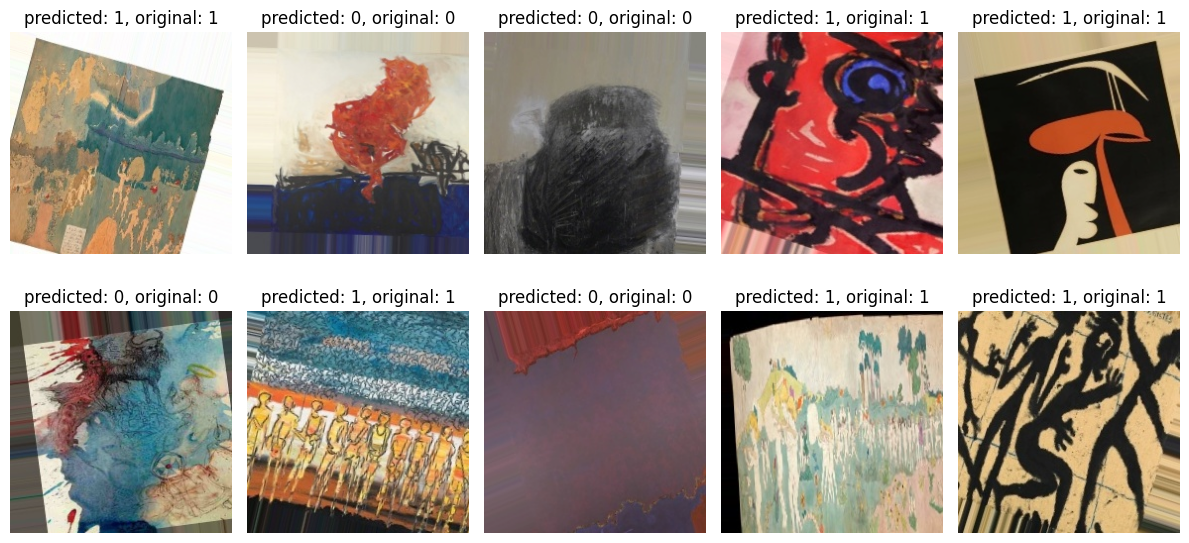

In [ ]:
 #Abstract_Expressionism    
num_images = 10
images_so_far = 0
plt.figure(figsize=(12, 6))
with torch.no_grad():
    # Set to evaluation mode
    model1.eval()    
# Validation loop
for inputs, target in test_loader:
    # Tensors to gpu
    if torch.cuda.is_available():
        inputs, target = inputs.cuda(), target.cuda()
    else:
        inputs = inputs.to(device=device, dtype=torch.float32)
        target = target.to(device=device, dtype=torch.long)
    
    # Forward pass
    output = model1(inputs)
    
    _, preds = torch.max(output, 1)
    for j in range(inputs.size()[0]):
        images_so_far += 1
        
        
        ax = plt.subplot(2, 5, images_so_far)
        ax.axis('off')
        ax.set_title(f'predicted: {preds[j]}, original: {target[j]}')
        inp = inputs.cpu()[j].numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        inp = std * inp + mean
        inp = np.clip(inp, 0, 1)
        plt.imshow(inp)
    
        if images_so_far == num_images:
            model1.train(mode=model1.training)
            break
    if images_so_far == num_images:
        model1.train(mode=model1.training)
        break
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()
                
from sklearn.metrics import confusion_matrix
matriz_confusion = confusion_matrix(preds, target)

print("Matriz de confusión")
print(matriz_confusion)

Text(0.5, 1.0, 'Training and Validation Accuracy')

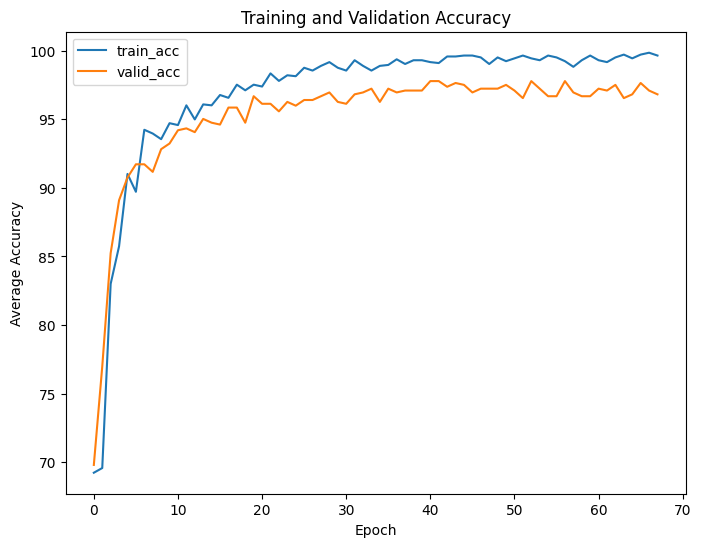

In [ ]:
#Abstract_Expressionism
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 6))
for c in ['train_acc', 'valid_acc']:
    plt.plot(
        100 * history1[c], label=c)
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Average Accuracy')
plt.title('Training and Validation Accuracy')

Text(0.5, 1.0, 'Training and Validation Accuracy')

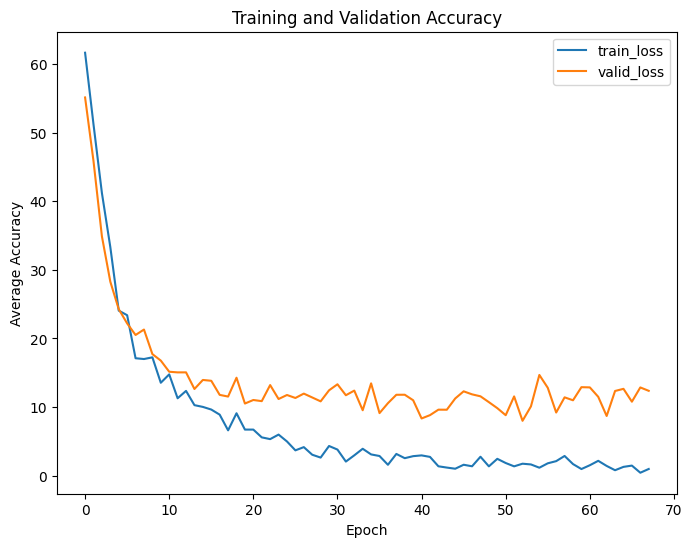

In [ ]:
#Abstract_Expressionism
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 6))
for c in ['train_loss', 'valid_loss']:
    plt.plot(
        100 * history1[c], label=c)
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Average Accuracy')
plt.title('Training and Validation Accuracy')

In [ ]:
Accuracy = metrics.accuracy_score(actual, predicted)
Precision = metrics.precision_score(actual, predicted)
Sensitivity_recall = metrics.recall_score(actual, predicted)
Specificity = metrics.recall_score(actual, predicted, pos_label=0)
F1_score = metrics.f1_score(actual, predicted)

In [ ]:
print({"Accuracy":round(accuracy.item(), 5),"Precision":round(Precision.item(), 5),"Sensitivity_recall":round(Sensitivity_recall.item(), 3),"Specificity":round(Specificity.item(), 3),"F1_score":round(F1_score.item(), 3)})

{'Accuracy': 1.0, 'Precision': 1.0, 'Sensitivity_recall': 1.0, 'Specificity': 1.0, 'F1_score': 1.0}
